# E03:
use the dev set to tune the strength of smoothing (or regularization) for the trigram model - i.e. try many possibilities and see which one works best based on the dev set loss. What patterns can you see in the train and dev set loss as you tune this strength? Take the best setting of the smoothing and evaluate on the test set once and at the end. How good of a loss do you achieve?

In [2]:
# import
import random
import torch
import torch.nn.functional as F

In [3]:
# split data set
words = open('../../../data/name.txt', 'r').read().splitlines()
random.seed(42)  # make the split reproducible so the two models compare on the same split
random.shuffle(words)
n_words = len(words)
n_train = int(0.8 * n_words)
n_dev = int(0.1 * n_words)
train_words = words[:n_train]
dev_words = words[n_train: (n_train + n_dev)]
test_words = words[(n_train + n_dev):]
print(len(train_words), len(dev_words), len(test_words))

# build stoi and itos
chars = sorted(list(set("".join(words))))
stoi = {s: i + 1 for i, s in enumerate(chars)}
stoi["."] = 0
itos = {i: s for s, i in stoi.items()}

25626 3203 3204


In [25]:
# trigram model
def parse_trigram_data(words):
    xs, ys, zs = [], [], []
    for w in words:
        chs = ["."] + ["."] + list(w) + ["."]
        for ch1, ch2, ch3 in zip(chs, chs[1:], chs[2:]):
            ix1 = stoi[ch1]
            ix2 = stoi[ch2]
            ix3 = stoi[ch3]
            xs.append(ix1)
            ys.append(ix2)
            zs.append(ix3)

    xs = torch.tensor(xs)
    ys = torch.tensor(ys)
    zs = torch.tensor(zs)
    return xs, ys, zs

# create the training set of trigrams
def train_trigram_model(lmbda=0.1, n_iter=500):
    xs, ys, zs = parse_trigram_data(train_words)
    n_train_data = len(xs)

    # initialize the network
    g = torch.Generator().manual_seed(2147483647)
    W = torch.randn((27, 27, 27), generator=g, requires_grad=True)

    # gradient descent
    # the trigram has 27x more parameters (27^3) than the bigram, and each of the
    # 729 context slices only sees a sparse share of the gradient, so it needs far
    # more iterations than the bigram to actually fit the training set.
    for k in range(n_iter):
        # forward pass
        # W3[xs, ys] is advanced indexing: for every example i it plucks the row
        # W3[xs[i], ys[i], :], producing (num, 27) logits. this is the learned
        # analogue of looking up N3[ix1, ix2] in the first approach.
        logits = W[xs, ys]  # (num, 27) log-counts
        counts = logits.exp()  # (num, 27) counts ~ N3
        probs = counts / counts.sum(1, keepdim=True)  # (num, 27) softmax -> P3
        # L2 regularization: lmbda controls the smoothing strength. larger lmbda
        # pushes W toward 0, which flattens the predicted distribution toward
        # uniform (the learned analogue of add-k smoothing on the counts).
        loss = -probs[torch.arange(n_train_data), zs].log().mean() + lmbda * (W**2).mean()

        # backward pass
        W.grad = None
        loss.backward()

        # update
        W.data += -50 * W.grad
    
    return W

@torch.no_grad()
def evaluate_trigram_model(W, evaluate_words):
    xs, ys, zs = parse_trigram_data(evaluate_words)
    n = len(xs)

    logits = W[xs, ys]  # (num, 27) log-counts
    counts = logits.exp()  # (num, 27) counts ~ N3
    probs = counts / counts.sum(1, keepdim=True)  # (num, 27) softmax -> P3
    loss = -probs[torch.arange(n), zs].log().mean()

    return loss.item()


In [32]:
# plot function
import matplotlib.pyplot as plt
%matplotlib inline

def plot_log_scale(n_iter=100):
    # generate data
    lmbdas = torch.logspace(-3, 0, 21).tolist()
    train_losses, dev_losses = [], []
    for lmbda in lmbdas:
        W_tri = train_trigram_model(lmbda=lmbda, n_iter=n_iter)
        train_losses.append(evaluate_trigram_model(W_tri, train_words))
        dev_losses.append(evaluate_trigram_model(W_tri, dev_words))

    # plot train and dev loss vs lmbda, x axis in log scale
    plt.figure(figsize=(7, 4))
    plt.plot(lmbdas, train_losses, marker="o", label="train")
    plt.plot(lmbdas, dev_losses, marker="o", label="dev")
    plt.xscale("log")
    plt.xlabel("lambda (smoothing strength, log scale)")
    plt.ylabel("loss (NLL)")
    plt.title("trigram smoothing strength vs loss")
    plt.legend()
    plt.grid(True, which="both", alpha=0.3)
    plt.show()

    lmbda, min_loss = sorted(list(zip(lmbdas, dev_losses)), key = lambda x: x[1])[0]
    print(f"min_loss = {min_loss} at lambda = {lmbda}")



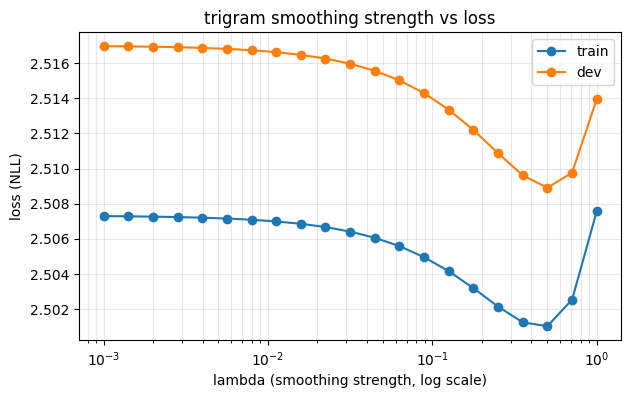

min_loss = 2.508903980255127 at lambda = 0.5011872053146362


In [33]:
plot_log_scale(n_iter=100)

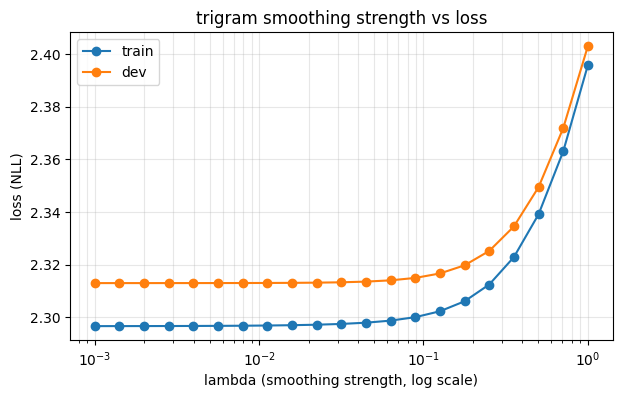

min_loss = 2.312959909439087 at lambda = 0.0010000000474974513


In [34]:
plot_log_scale(n_iter=400)